In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.test.is_built_with_cuda())
print(tf.test.is_built_with_cuda())





In [2]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.layers import Flatten,Dense,Conv2D, MaxPooling2D, Conv2DTranspose, Dropout, Input,UpSampling2D,BatchNormalization,Activation
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, jaccard_score
from sklearn.metrics import average_precision_score, accuracy_score
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score, accuracy_score,precision_recall_fscore_support
import matplotlib.pyplot as plt
DATASET_PATH = "/content/data/VOCdevkit/VOC2008"
IMAGE_DIR = os.path.join(DATASET_PATH, "JPEGImages")
ANN_DIR = os.path.join(DATASET_PATH, "Annotations")
SPLIT_FILE = os.path.join(DATASET_PATH, "ImageSets/Main/train.txt")

VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
class_to_idx = {cls: i for i, cls in enumerate(VOC_CLASSES)}
# print(len(class_to_idx))

TASK 1 Classicfication

In [3]:

IMG_SIZE = (128, 128)
images = []
labels = []

with open(SPLIT_FILE, 'r') as f:
    img_ids = f.read().strip().split()

for img_id in img_ids:
    img_path = os.path.join(IMAGE_DIR, img_id + ".jpg")
    ann_path = os.path.join(ANN_DIR, img_id + ".xml")

    try:
        img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
        img = np.array(img) / 255.0  # Normalize
    except:
        continue

    label = np.zeros(len(VOC_CLASSES))
    try:
        tree = ET.parse(ann_path)
        root = tree.getroot()
        for obj in root.findall("object"):
            cls = obj.find("name").text.lower().strip()
            if cls in class_to_idx:
                label[class_to_idx[cls]] = 1.0
    except:
        continue

    images.append(img)
    labels.append(label)

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.float32)
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

print(X_train.shape,X_val.shape)

print("Images X:", images.shape)
print("Labels y:", labels.shape)


(1688, 128, 128, 3) (423, 128, 128, 3)
Images X: (2111, 128, 128, 3)
Labels y: (2111, 20)


In [4]:
# X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).shuffle(1000)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)


model = models.Sequential([
Input(shape=(128, 128, 3)),
    Conv2D(32, 3, activation='relu',padding='same'),
    MaxPooling2D(),
    Conv2D(64, 3, activation='relu',padding='same'),
    MaxPooling2D(),
    Conv2D(128, 3, activation='relu',padding='same'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(VOC_CLASSES), activation='sigmoid')   # multi-label
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=30,
#     batch_size=32
# )
model.fit(train_ds, validation_data=val_ds, epochs=10)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,194,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │           2,580 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,290,260 (16.37 MB)

 Trainable params: 4,290,260 (16.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, average_precision_score, accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#test
y_pred = model.predict(X_val)
y_pred_tresh=(y_pred > 0.5).astype(int)

# metricc
print(classification_report(y_val, y_pred_tresh, target_names=VOC_CLASSES, zero_division=0))
mAP = average_precision_score(y_val, y_pred)
accuracy = accuracy_score(y_val.flatten(), y_pred_tresh.flatten())
print(f"Accuracy: {accuracy:.4f}")
print("mAp",mAP)


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 298ms/step
              precision    recall  f1-score   support

   aeroplane       0.67      0.22      0.33        27
     bicycle       1.00      0.05      0.10        20
        bird       0.08      0.07      0.08        28
        boat       0.40      0.14      0.21        29
      bottle       0.06      0.03      0.04        33
         bus       0.00      0.00      0.00        13
         car       0.27      0.22      0.24        54
         cat       0.13      0.06      0.08        36
       chair       0.17      0.11      0.14        35
         cow       0.00      0.00      0.00         4
 diningtable       0.00      0.00      0.00        19
         dog       0.10      0.03      0.04        38
       horse       0.00      0.00      0.00        16
   motorbike       0.00      0.00      0.00        23
      person       0.58      0.65      0.61       207
 pottedplant       0.00      0.00      0.00        24
       sheep       0.00      0.00      0

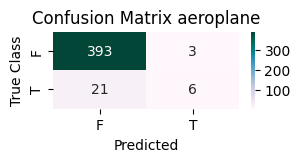

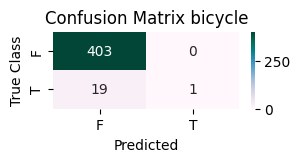

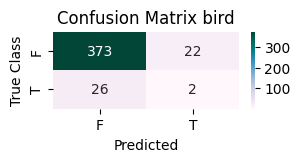

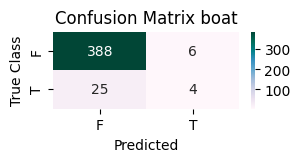

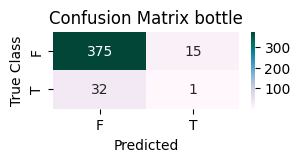

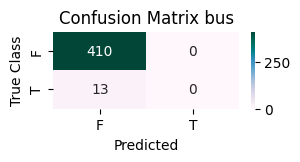

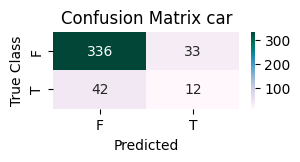

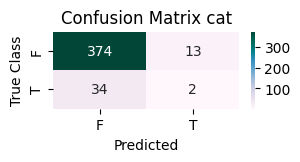

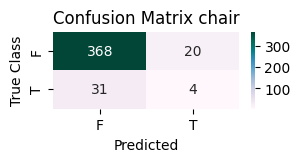

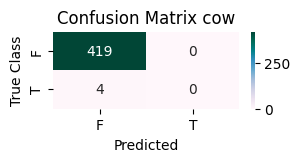

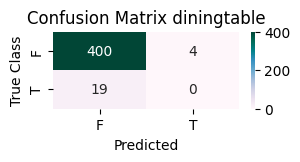

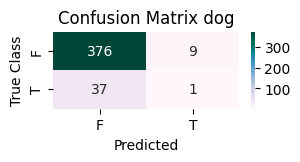

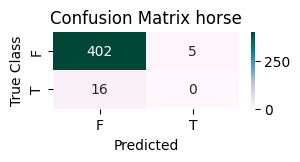

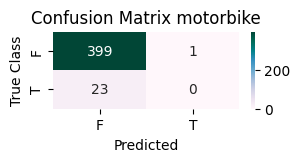

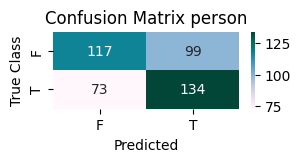

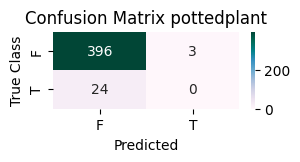

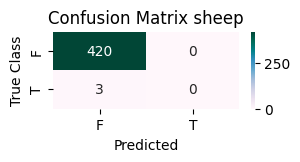

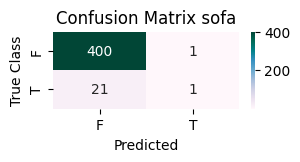

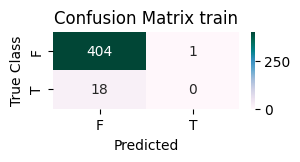

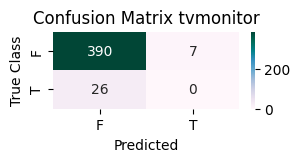

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


for i in range(len(VOC_CLASSES)):
    true_class = y_val[:, i]
    pred_class = y_pred_tresh[:, i]
    cm = confusion_matrix(true_class, pred_class)

    # Plot confusion matrix
    plt.figure(figsize=(3, 1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn',
                xticklabels=["F","T"], yticklabels=["F","T"])
    plt.title("Confusion Matrix " +VOC_CLASSES[i])
    plt.xlabel("Predicted")
    plt.ylabel("True Class")
    plt.show()
